
📥 Downloading price data from Yahoo Finance...
   Period: 2022-01-01 → 2026-03-27

✅ Retrieved 16 tickers.
   Date range: 2022-01-04 → 2026-03-26



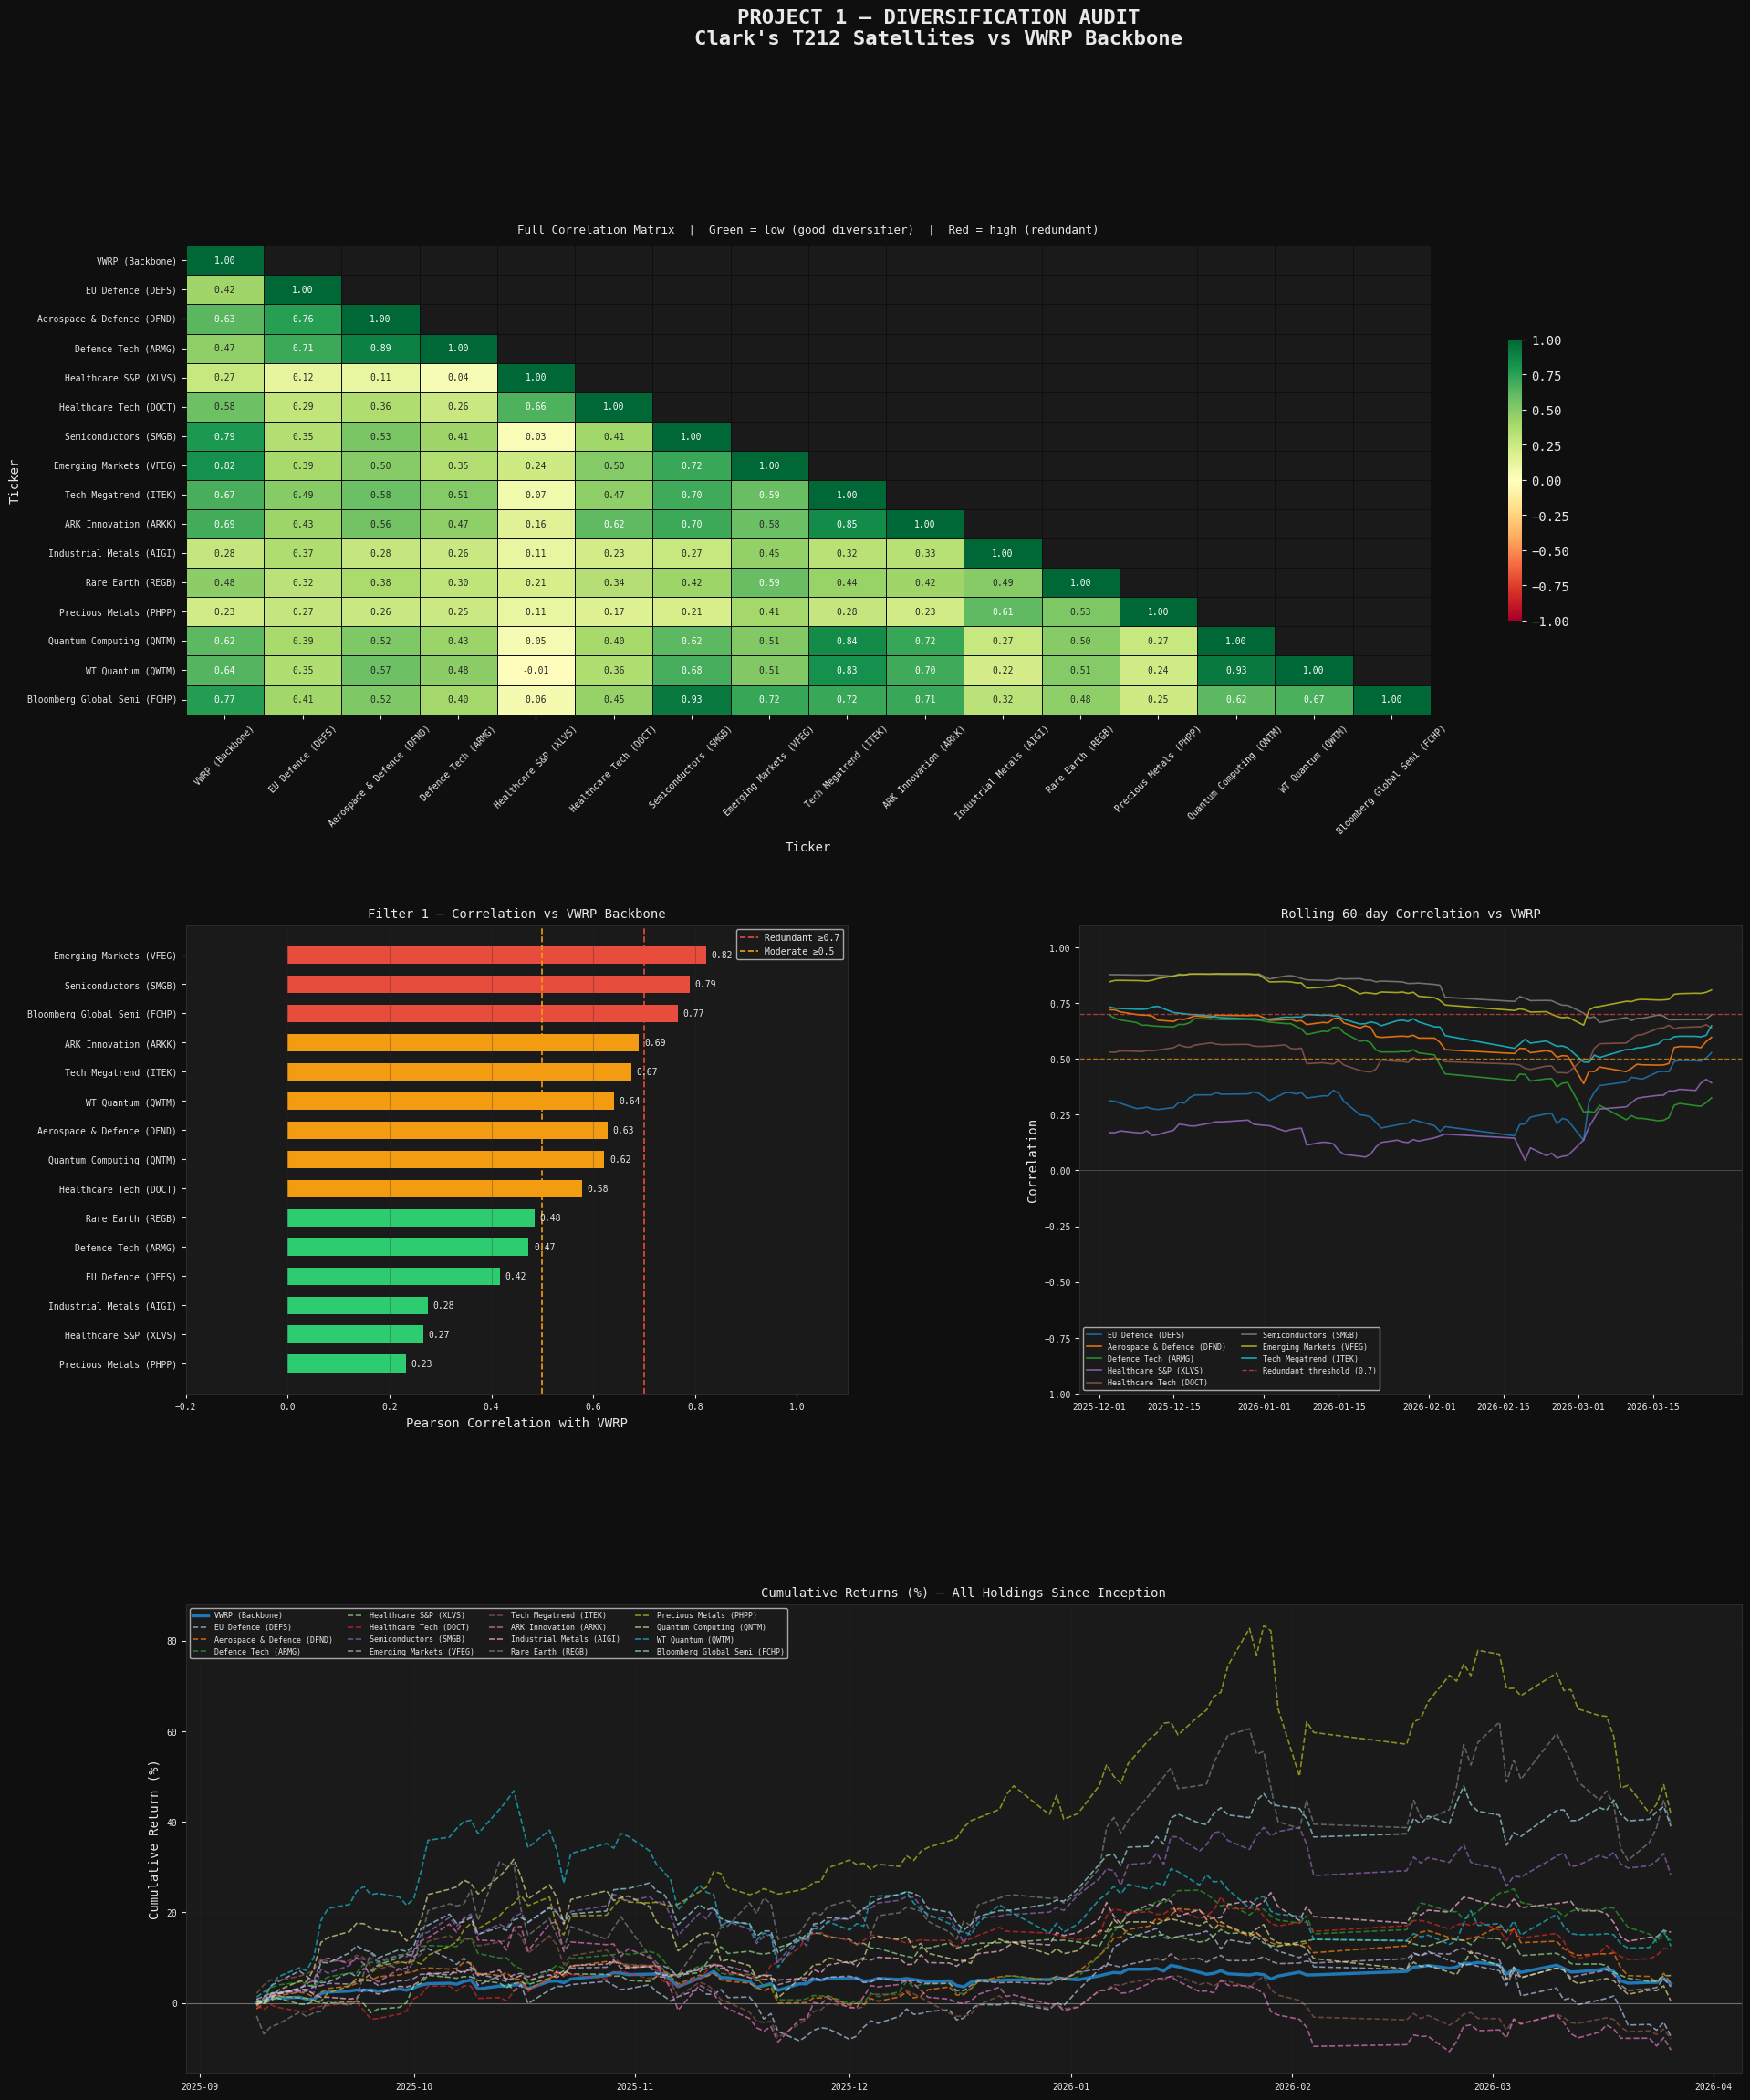

  FILTER 1 — DIVERSIFICATION VERDICT vs VWRP
  ETF                                   Corr   Verdict
-----------------------------------------------------------------
  Emerging Markets (VFEG)              0.822   ❌ Redundant
  Semiconductors (SMGB)                0.790   ❌ Redundant
  Bloomberg Global Semi (FCHP)         0.767   ❌ Redundant
  ARK Innovation (ARKK)                0.690   ⚠️  Moderate overlap
  Tech Megatrend (ITEK)                0.674   ⚠️  Moderate overlap
  WT Quantum (QWTM)                    0.641   ⚠️  Moderate overlap
  Aerospace & Defence (DFND)           0.628   ⚠️  Moderate overlap
  Quantum Computing (QNTM)             0.622   ⚠️  Moderate overlap
  Healthcare Tech (DOCT)               0.578   ⚠️  Moderate overlap
  Rare Earth (REGB)                    0.484   ✅ Good diversifier
  Defence Tech (ARMG)                  0.473   ✅ Good diversifier
  EU Defence (DEFS)                    0.417   ✅ Good diversifier
  Industrial Metals (AIGI)             0.275   ✅ Go

In [1]:
"""
============================================================
 PROJECT 1 — DIVERSIFICATION AUDIT
 Clark's T212 Satellite Portfolio vs VWRP Backbone
============================================================

WHAT THIS SCRIPT DOES:
  Filter 1  — Correlation of each satellite vs VWRP
  Filter 2b — Cross-correlation between satellites

KEY CONCEPTS:
  Pearson Correlation: measures linear relationship between
  two return series. Range: -1 to +1. We want satellites
  below 0.6 vs VWRP to justify holding them.

  Covariance Matrix: the mathematical foundation beneath
  the correlation matrix. Correlation is just normalised
  covariance — you'll use this heavily in Project 3 (MVO).

  Rolling Correlation: correlation over a moving window
  (e.g. 60 days) — shows how the relationship CHANGES
  over time, not just on average.
============================================================
"""

# ── IMPORTS ──────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURATION ─────────────────────────────────────────
# London-listed ETFs use the .L suffix on Yahoo Finance.
# Edit this dict freely to add/remove holdings.

HOLDINGS = {
    'VWRP.L':  'VWRP (Backbone)',
    'DEFS.L':  'EU Defence (DEFS)',
    'DFND.L':  'Aerospace & Defence (DFND)',
    'ARMG.L':  'Defence Tech (ARMG)',
    'XLVS.L':  'Healthcare S&P (XLVS)',
    'DOCT.L':  'Healthcare Tech (DOCT)',
    'SMGB.L':  'Semiconductors (SMGB)',
    'VFEG.L':  'Emerging Markets (VFEG)',
    'ITEK.L':  'Tech Megatrend (ITEK)',
    'ARKK.L':  'ARK Innovation (ARKK)',
    'AIGI.L':  'Industrial Metals (AIGI)',
    'REGB.L':  'Rare Earth (REGB)',
    'PHPP.L':  'Precious Metals (PHPP)',
    'QNTM.L':  'Quantum Computing (QNTM)',
    'QWTM.L':  'WT Quantum (QWTM)',
    'FCHP.L':  'Bloomberg Global Semi (FCHP)',
}

BACKBONE    = 'VWRP.L'       # Correlation anchor
START_DATE  = '2022-01-01'   # Far enough back to capture a full market cycle
END_DATE    = '2026-03-27'

CORR_WINDOW          = 60    # Rolling window in trading days (~3 months)
HIGH_CORR_VS_VWRP    = 0.70  # Above this → redundant vs backbone
MEDIUM_CORR_VS_VWRP  = 0.50  # Between 0.5–0.7 → moderate overlap
HIGH_CROSS_CORR      = 0.75  # Above this → satellites doubling up on same bet

# ── STYLE ─────────────────────────────────────────────────
PALETTE = {
    'background': '#0f0f0f',
    'panel':      '#1a1a1a',
    'text':       '#e8e8e8',
    'green':      '#2ecc71',
    'amber':      '#f39c12',
    'red':        '#e74c3c',
    'blue':       '#3498db',
    'grid':       '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['background'],
    'axes.facecolor':   PALETTE['panel'],
    'axes.edgecolor':   PALETTE['grid'],
    'axes.labelcolor':  PALETTE['text'],
    'xtick.color':      PALETTE['text'],
    'ytick.color':      PALETTE['text'],
    'text.color':       PALETTE['text'],
    'grid.color':       PALETTE['grid'],
    'font.family':      'monospace',
})


# ── STEP 1: DOWNLOAD PRICE DATA ───────────────────────────
print("\n📥 Downloading price data from Yahoo Finance...")
print(f"   Period: {START_DATE} → {END_DATE}\n")

tickers = list(HOLDINGS.keys())
raw = yf.download(tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close']

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

available = [t for t in tickers if t in raw.columns and raw[t].notna().sum() > 30]
missing   = [t for t in tickers if t not in available]

if missing:
    print(f"⚠️  Could not retrieve: {missing}\n   Excluded from analysis.\n")

prices = raw[available].dropna(how='all')
print(f"✅ Retrieved {len(available)} tickers.")
print(f"   Date range: {prices.index[0].date()} → {prices.index[-1].date()}\n")


# ── STEP 2: COMPUTE DAILY RETURNS ─────────────────────────
# WHY returns not prices?
# Price levels are non-stationary (they trend upward).
# Correlation requires stationary inputs — returns satisfy this.
# pct_change() = (P_t - P_{t-1}) / P_{t-1}

returns = prices.pct_change().dropna()

short_names = {t: HOLDINGS[t] for t in available if t in HOLDINGS}
returns.rename(columns=short_names, inplace=True)
prices.rename(columns=short_names, inplace=True)

backbone_name = HOLDINGS[BACKBONE]


# ── STEP 3: CORRELATION MATRIX ────────────────────────────
# R[i,j] = cov(i,j) / (std(i) * std(j))
# This is the normalised covariance matrix. Values in [-1, 1].

corr_matrix = returns.corr()


# ── STEP 4: FILTER 1 — CORRELATION VS VWRP ───────────────
corr_vs_vwrp = (corr_matrix[backbone_name]
                .drop(backbone_name)
                .sort_values())

def verdict_vs_vwrp(c):
    if c >= HIGH_CORR_VS_VWRP:
        return '❌ Redundant'
    elif c >= MEDIUM_CORR_VS_VWRP:
        return '⚠️  Moderate overlap'
    else:
        return '✅ Good diversifier'


# ── STEP 5: ROLLING CORRELATION ───────────────────────────
# Static correlation hides regime changes.
# e.g. defence had LOW correlation with VWRP pre-2022,
# then spiked after the Ukraine invasion — static correlation
# averages this out and loses the signal.

rolling_corr = (returns
                .drop(columns=[backbone_name])
                .rolling(CORR_WINDOW)
                .corr(returns[backbone_name])
                .dropna())


# ── STEP 6: CUMULATIVE RETURNS ────────────────────────────
# (1 + r).cumprod() - 1 compounds daily returns from inception.

cum_returns = (1 + returns).cumprod() - 1


# ══════════════════════════════════════════════════════════
#  CHARTS
# ══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 26))
fig.suptitle(
    "PROJECT 1 — DIVERSIFICATION AUDIT\nClark's T212 Satellites vs VWRP Backbone",
    fontsize=16, fontweight='bold', color=PALETTE['text'], y=0.98
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)


# Chart 1: Full Correlation Heatmap
ax1 = fig.add_subplot(gs[0, :])
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor=PALETTE['background'],
    annot_kws={'size': 7}, ax=ax1, cbar_kws={'shrink': 0.6}
)
ax1.set_title(
    'Full Correlation Matrix  |  Green = low (good diversifier)  |  Red = high (redundant)',
    fontsize=9, pad=10
)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.tick_params(axis='y', rotation=0,  labelsize=7)


# Chart 2: Correlation vs VWRP bar chart
ax2 = fig.add_subplot(gs[1, 0])
colours = [
    PALETTE['red']   if c >= HIGH_CORR_VS_VWRP   else
    PALETTE['amber'] if c >= MEDIUM_CORR_VS_VWRP  else
    PALETTE['green']
    for c in corr_vs_vwrp.values
]
bars = ax2.barh(corr_vs_vwrp.index, corr_vs_vwrp.values,
                color=colours, edgecolor='none', height=0.6)
ax2.axvline(HIGH_CORR_VS_VWRP,   color=PALETTE['red'],   ls='--', lw=1.2,
            label=f'Redundant ≥{HIGH_CORR_VS_VWRP}')
ax2.axvline(MEDIUM_CORR_VS_VWRP, color=PALETTE['amber'], ls='--', lw=1.2,
            label=f'Moderate ≥{MEDIUM_CORR_VS_VWRP}')
ax2.set_xlabel('Pearson Correlation with VWRP')
ax2.set_title('Filter 1 — Correlation vs VWRP Backbone', fontsize=10)
ax2.legend(fontsize=7)
ax2.set_xlim(-0.2, 1.1)
ax2.tick_params(labelsize=7)
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, corr_vs_vwrp.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=7, color=PALETTE['text'])


# Chart 3: Rolling Correlation vs VWRP
ax3 = fig.add_subplot(gs[1, 1])
sat_cols   = [c for c in rolling_corr.columns if c != backbone_name][:8]
cmap_lines = plt.cm.tab10(np.linspace(0, 1, len(sat_cols)))
for col, colour in zip(sat_cols, cmap_lines):
    if col in rolling_corr.columns:
        ax3.plot(rolling_corr.index, rolling_corr[col],
                 label=col, lw=1.2, color=colour, alpha=0.85)
ax3.axhline(HIGH_CORR_VS_VWRP,   color=PALETTE['red'],   ls='--', lw=1, alpha=0.7,
            label=f'Redundant threshold ({HIGH_CORR_VS_VWRP})')
ax3.axhline(MEDIUM_CORR_VS_VWRP, color=PALETTE['amber'], ls='--', lw=1, alpha=0.7)
ax3.axhline(0, color=PALETTE['text'], ls='-', lw=0.5, alpha=0.3)
ax3.set_title(f'Rolling {CORR_WINDOW}-day Correlation vs VWRP', fontsize=10)
ax3.set_ylabel('Correlation')
ax3.set_ylim(-1, 1.1)
ax3.legend(fontsize=6, loc='lower left', ncol=2)
ax3.grid(alpha=0.2)
ax3.tick_params(labelsize=7)


# Chart 4: Cumulative Returns
ax4 = fig.add_subplot(gs[2, :])
cmap_ret = plt.cm.tab20(np.linspace(0, 1, len(cum_returns.columns)))
for col, colour in zip(cum_returns.columns, cmap_ret):
    lw    = 2.5 if col == backbone_name else 1.2
    alpha = 1.0 if col == backbone_name else 0.7
    ls    = '-'  if col == backbone_name else '--'
    ax4.plot(cum_returns.index, cum_returns[col] * 100,
             label=col, lw=lw, color=colour, alpha=alpha, ls=ls)
ax4.axhline(0, color=PALETTE['text'], lw=0.8, alpha=0.4)
ax4.set_title('Cumulative Returns (%) — All Holdings Since Inception', fontsize=10)
ax4.set_ylabel('Cumulative Return (%)')
ax4.legend(fontsize=6, ncol=4, loc='upper left')
ax4.grid(alpha=0.2)
ax4.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════
#  PRINTED VERDICT TABLES
# ══════════════════════════════════════════════════════════

print("=" * 65)
print("  FILTER 1 — DIVERSIFICATION VERDICT vs VWRP")
print("=" * 65)
print(f"  {'ETF':<35} {'Corr':>6}   Verdict")
print("-" * 65)
for etf, corr in corr_vs_vwrp.sort_values(ascending=False).items():
    print(f"  {etf:<35} {corr:>6.3f}   {verdict_vs_vwrp(corr)}")
print("=" * 65)

print("\n" + "=" * 65)
print("  FILTER 2b — HIGH CROSS-CORRELATION PAIRS")
print("=" * 65)
sat_cols = [c for c in corr_matrix.columns if c != backbone_name]
sat_corr = corr_matrix.loc[sat_cols, sat_cols]
pairs    = []
for i in range(len(sat_cols)):
    for j in range(i + 1, len(sat_cols)):
        c = sat_corr.iloc[i, j]
        if c >= HIGH_CROSS_CORR:
            pairs.append((sat_cols[i], sat_cols[j], c))
pairs.sort(key=lambda x: -x[2])
if pairs:
    for a, b, c in pairs:
        print(f"  ⚠️  {a:<28} ↔  {b:<26} ({c:.2f})")
else:
    print("  ✅ No highly correlated satellite pairs found.")
print("=" * 65)